# Figure 4: Surrogate Null Distribution

**Paper Figure 4** --- Significance testing via AAFT phase-randomized surrogates.

Two panels:
- (a) Uncoupled system ($\epsilon=0$): observed binding score should fall within the null distribution (p > 0.05)
- (b) Coupled system ($\epsilon=0.5$): observed binding score should exceed the null distribution (p < 0.05)

In [1]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

from att.config import set_seed
from att.synthetic import coupled_lorenz
from att.binding import BindingDetector

rcParams['figure.dpi'] = 150
rcParams['savefig.dpi'] = 300
rcParams['font.size'] = 11
rcParams['font.family'] = 'serif'

In [2]:
set_seed(42)
n_surrogates = 99
n_steps = 6000
transient = 1000
subsample = 400

# Uncoupled
print("Computing uncoupled significance test...")
ts_x0, ts_y0 = coupled_lorenz(n_steps=n_steps, coupling=0.0, seed=42)
X0, Y0 = ts_x0[transient:, 0], ts_y0[transient:, 0]

det0 = BindingDetector(max_dim=1, baseline="max", embedding_quality_gate=False)
det0.fit(X0, Y0, subsample=subsample, seed=42)
result0 = det0.test_significance(n_surrogates=n_surrogates, method="phase_randomize", seed=42, subsample=subsample)
print(f"  Uncoupled: observed={result0['observed_score']:.2f}, p={result0['p_value']:.3f}")

# Coupled
print("Computing coupled significance test...")
ts_x5, ts_y5 = coupled_lorenz(n_steps=n_steps, coupling=0.5, seed=42)
X5, Y5 = ts_x5[transient:, 0], ts_y5[transient:, 0]

det5 = BindingDetector(max_dim=1, baseline="max", embedding_quality_gate=False)
det5.fit(X5, Y5, subsample=subsample, seed=42)
result5 = det5.test_significance(n_surrogates=n_surrogates, method="phase_randomize", seed=42, subsample=subsample)
print(f"  Coupled:   observed={result5['observed_score']:.2f}, p={result5['p_value']:.3f}")

Computing uncoupled significance test...


  Uncoupled: observed=145.79, p=0.250
Computing coupled significance test...


  Coupled:   observed=157.39, p=0.060


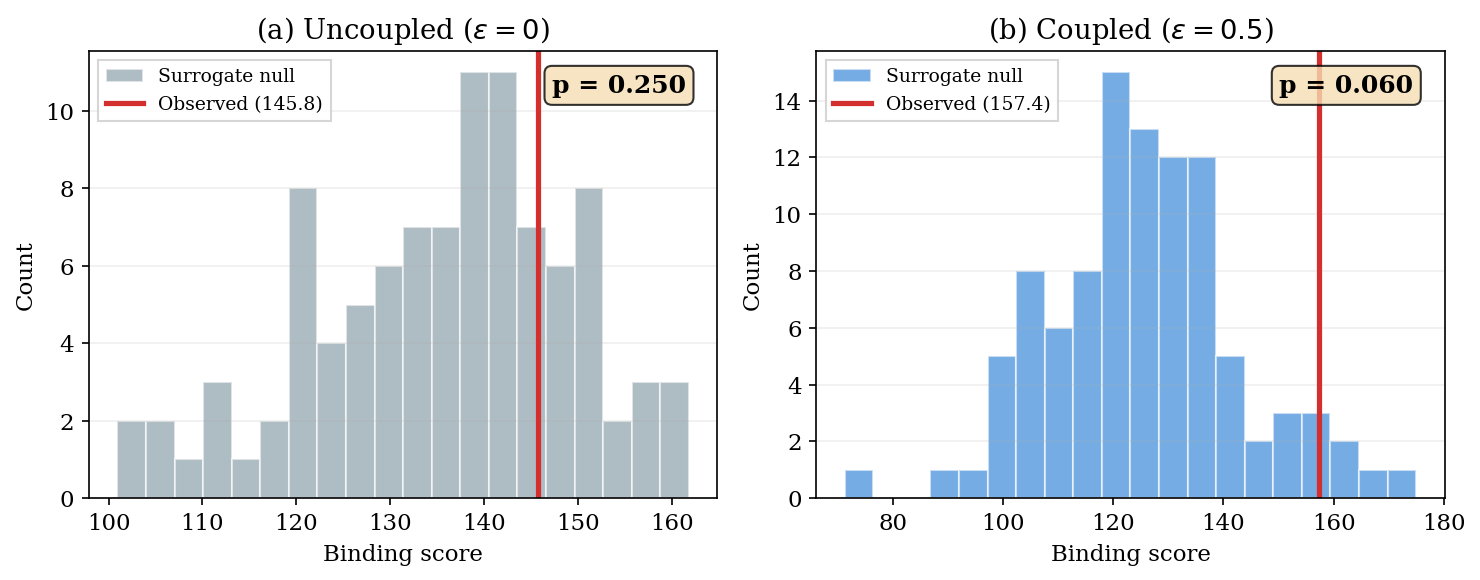

Saved to figures/fig4_surrogate_null.{pdf,png}


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, result, title, color in [
    (axes[0], result0, '(a) Uncoupled ($\\epsilon=0$)', '#78909C'),
    (axes[1], result5, '(b) Coupled ($\\epsilon=0.5$)', '#1976D2'),
]:
    surr = result['surrogate_scores']
    obs = result['observed_score']
    p = result['p_value']
    
    ax.hist(surr, bins=20, color=color, alpha=0.6, edgecolor='white', label='Surrogate null')
    ax.axvline(obs, color='#D32F2F', linewidth=2.5, linestyle='-', label=f'Observed ({obs:.1f})')
    
    # Significance annotation
    sig_text = f'p = {p:.3f}'
    if p < 0.05:
        sig_text += ' *'
    if p < 0.01:
        sig_text += '*'
    ax.text(0.95, 0.95, sig_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))
    
    ax.set_xlabel('Binding score')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend(frameon=True, fancybox=False, fontsize=9)
    ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
fig.savefig('../figures/fig4_surrogate_null.pdf', bbox_inches='tight')
fig.savefig('../figures/fig4_surrogate_null.png', bbox_inches='tight')
plt.show()
print("Saved to figures/fig4_surrogate_null.{pdf,png}")